# Project Objective

This project analyses historical Gemini marketing campaign data and brand lift study results to identify which markets, channels, campaigns and creatives generate the strongest and most efficient outcomes.

Questions:
- Which campaigns generate the highest brand lift?
- Which campaigns are most cost-efficient?
- Which markets and channels perform best?
- Which channels are most/least expensive to target?
- Which creatives resonate best?
- Does creative performance differ by market?
- Are there relationships between spend, reach and lift?

In [125]:
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load data

In [126]:
bls_df = pd.read_csv('../data/raw/Brand Lift Study Results - Sheet1.csv')
historic_df = pd.read_csv('../data/raw/Historic Campaign Data - Sheet1.csv')
creative_df = pd.read_csv('../data/raw/Creative Performance Report - Sheet1.csv')

## Data Exploration

Brand Lift Dataset

In [127]:
bls_df.head()

,Campaign_Name,Market,Channel,Control_Responses,Control_Consideration,Exposed_Responses,Exposed_Consideration,Control_Rate,Exposed_Rate,Relative_Lift
0,BackToSchool_23,UK,YouTube,1824,273,2204,595,0.149671,0.269964,80.371353
1,BackToSchool_23,UK,Social,2473,370,1460,364,0.149616,0.249315,66.636801
2,BackToSchool_23,UK,Display,1741,261,1348,215,0.149914,0.159496,6.391475
3,BackToSchool_23,DE,YouTube,2236,335,1566,425,0.149821,0.271392,81.144088
4,BackToSchool_23,DE,Social,2269,340,1134,273,0.149846,0.240741,60.659041


In [128]:
bls_df.shape

(48, 10)

In [129]:
bls_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Campaign_Name          48 non-null     str    
 1   Market                 48 non-null     str    
 2   Channel                48 non-null     str    
 3   Control_Responses      48 non-null     int64  
 4   Control_Consideration  48 non-null     int64  
 5   Exposed_Responses      48 non-null     int64  
 6   Exposed_Consideration  48 non-null     int64  
 7   Control_Rate           48 non-null     float64
 8   Exposed_Rate           48 non-null     float64
 9   Relative_Lift          48 non-null     float64
dtypes: float64(3), int64(4), str(3)
memory usage: 4.9 KB


In [130]:
bls_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Control_Responses,48.0,2011.229167,564.256289,1046.000000,1602.250000,2108.000000,2399.250000,2964.000000
Control_Consideration,48.0,301.187500,84.649881,156.000000,240.000000,315.500000,359.250000,444.000000
Exposed_Responses,48.0,2036.354167,606.552395,1104.000000,1402.750000,2175.000000,2592.250000,2920.000000
Exposed_Consideration,48.0,488.291667,184.863602,202.000000,361.750000,438.500000,629.250000,877.000000
Control_Rate,48.0,0.149727,0.000192,0.149140,0.149620,0.149772,0.149850,0.150000
Exposed_Rate,48.0,0.240334,0.052812,0.158098,0.182572,0.262887,0.276711,0.305065
Relative_Lift,48.0,60.516320,35.277216,5.706233,22.141977,75.637235,84.759966,103.931185


In [131]:
bls_df.isnull().sum()

Campaign_Name            0
Market                   0
Channel                  0
Control_Responses        0
Control_Consideration    0
Exposed_Responses        0
Exposed_Consideration    0
Control_Rate             0
Exposed_Rate             0
Relative_Lift            0
dtype: int64

In [132]:
bls_df.nunique()

Campaign_Name             4
Market                    4
Channel                   3
Control_Responses        46
Control_Consideration    41
Exposed_Responses        47
Exposed_Consideration    48
Control_Rate             46
Exposed_Rate             48
Relative_Lift            48
dtype: int64

In [133]:
bls_df["Market"].value_counts()

Market
UK    12
DE    12
SA    12
EG    12
Name: count, dtype: int64

In [134]:
bls_df["Channel"].value_counts()

Channel
YouTube    16
Social     16
Display    16
Name: count, dtype: int64

In [135]:
bls_df["Campaign_Name"].value_counts()

Campaign_Name
BackToSchool_23    12
ExamPrep_23        12
NewYear_24         12
BackToSchool_24    12
Name: count, dtype: int64

Historic Campaign Dataset

In [136]:
historic_df.head()

,Week_Start,Week_Date,Campaign_Name,Market,Channel,Spend_USD,Impressions,Reach,Conversions
0,2023-01-02,2023-01-02,Always_On,UK,YouTube,6212,331780,111134,214
1,2023-01-02,2023-01-02,Always_On,UK,Social,4262,318639,154596,137
2,2023-01-02,2023-01-02,Always_On,UK,Display,2009,515503,101883,18
3,2023-01-02,2023-01-02,Always_On,UK,Search,5513,67707,61330,466
4,2023-01-02,2023-01-02,Always_On,DE,YouTube,5664,426034,190810,173


In [137]:
historic_df.shape

(1664, 9)

In [138]:
historic_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1664 entries, 0 to 1663
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Week_Start     1664 non-null   str  
 1   Week_Date      1664 non-null   str  
 2   Campaign_Name  1664 non-null   str  
 3   Market         1664 non-null   str  
 4   Channel        1664 non-null   str  
 5   Spend_USD      1664 non-null   int64
 6   Impressions    1664 non-null   int64
 7   Reach          1664 non-null   int64
 8   Conversions    1664 non-null   int64
dtypes: int64(4), str(5)
memory usage: 179.8 KB


In [139]:
historic_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Spend_USD,1664.0,6380.615986,5054.519868,1203.0,3131.75,4479.0,7253.75,28580.0
Impressions,1664.0,539778.913462,624864.921066,20681.0,167983.50,341028.5,660352.00,4369702.0
Reach,1664.0,173807.406250,157013.023497,18713.0,75155.75,122498.5,199425.00,1020650.0
Conversions,1664.0,571.172476,746.391781,13.0,128.75,335.5,656.25,5806.0


In [140]:
historic_df.isnull().sum()

Week_Start       0
Week_Date        0
Campaign_Name    0
Market           0
Channel          0
Spend_USD        0
Impressions      0
Reach            0
Conversions      0
dtype: int64

In [141]:
historic_df["Market"].value_counts()

Market
UK    416
DE    416
SA    416
EG    416
Name: count, dtype: int64

In [142]:
historic_df["Channel"].value_counts()

Channel
YouTube    416
Social     416
Display    416
Search     416
Name: count, dtype: int64

In [143]:
historic_df["Campaign_Name"].value_counts()

Campaign_Name
Always_On          1248
BackToSchool_23     128
BackToSchool_24     128
ExamPrep_23          96
NewYear_24           64
Name: count, dtype: int64

Creative Dataset

In [144]:
creative_df.head()

,Report_Date,Creative_Name,Market,Channel,Age_Group,Point_Est_Awareness,Point_Est_Consideration,Point_Est_Purchase_Intent
0,2026-01-15,Study With Me,UK,YouTube,18-24,6.07,4.00,1.62
1,2026-01-15,Study With Me,UK,YouTube,25-34,6.20,4.07,1.41
2,2026-01-15,Study With Me,UK,YouTube,35-49,5.80,3.53,1.39
3,2026-01-15,Study With Me,UK,Social,18-24,4.80,3.52,1.55
4,2026-01-15,Study With Me,UK,Social,25-34,5.21,3.61,1.61


In [145]:
creative_df.shape

(240, 8)

In [146]:
creative_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Report_Date                240 non-null    str    
 1   Creative_Name              240 non-null    str    
 2   Market                     240 non-null    str    
 3   Channel                    240 non-null    str    
 4   Age_Group                  240 non-null    str    
 5   Point_Est_Awareness        240 non-null    float64
 6   Point_Est_Consideration    240 non-null    float64
 7   Point_Est_Purchase_Intent  240 non-null    float64
dtypes: float64(3), str(5)
memory usage: 23.3 KB


In [147]:
creative_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Point_Est_Awareness,240.0,5.145083,2.734932,0.91,3.6800,5.44,6.87,9.30
Point_Est_Consideration,240.0,2.709125,3.250843,0.11,0.6675,1.78,3.83,21.83
Point_Est_Purchase_Intent,240.0,3.395125,3.304128,1.35,1.4400,1.54,3.28,9.86


In [148]:
creative_df.isnull().sum()

Report_Date                  0
Creative_Name                0
Market                       0
Channel                      0
Age_Group                    0
Point_Est_Awareness          0
Point_Est_Consideration      0
Point_Est_Purchase_Intent    0
dtype: int64

In [149]:
creative_df["Market"].value_counts()

Market
UK    60
DE    60
SA    60
EG    60
Name: count, dtype: int64

In [150]:
creative_df["Channel"].value_counts()

Channel
YouTube    60
Social     60
Display    60
Search     60
Name: count, dtype: int64

In [151]:
creative_df["Creative_Name"].value_counts()

Creative_Name
Study With Me    48
Grade Booster    48
Life Hack        48
Free Trial       48
Coding Help      48
Name: count, dtype: int64

## Data Cleaning

In [152]:
#Check for duplicates
print("Brand Lift duplicates:", bls_df.duplicated().sum())
print("Campaign duplicates:", historic_df.duplicated().sum())
print("Creative duplicates:", creative_df.duplicated().sum())

Brand Lift duplicates: 0
Campaign duplicates: 0
Creative duplicates: 0


In [153]:
print(bls_df['Market'].unique())
print(bls_df['Channel'].unique())

print(historic_df['Market'].unique())
print(historic_df['Channel'].unique())

print(creative_df['Market'].unique())
print(creative_df['Channel'].unique())

<ArrowStringArray>
['UK', 'DE', 'SA', 'EG']
Length: 4, dtype: str
<ArrowStringArray>
['YouTube', 'Social', 'Display']
Length: 3, dtype: str
<ArrowStringArray>
['UK', 'DE', 'SA', 'EG']
Length: 4, dtype: str
<ArrowStringArray>
['YouTube', 'Social', 'Display', 'Search']
Length: 4, dtype: str
<ArrowStringArray>
['UK', 'DE', 'SA', 'EG']
Length: 4, dtype: str
<ArrowStringArray>
['YouTube', 'Social', 'Display', 'Search']
Length: 4, dtype: str


There are no null and duplicate values in the dataset and category names are consistent across the datasets. All values are needed for recommendation.

## Statistical Significance

Calculate p-value and is_significant

In [154]:
def calculate_p_value(row):
    # Successes: [Exposed, Control], Totals: [Exposed, Control]
    counts = [row['Exposed_Consideration'], row['Control_Consideration']]
    sample_size = [row['Exposed_Responses'], row['Control_Responses']]

    # Calculate p-value for this specific row
    stat, pval = proportions_ztest(counts, sample_size)

    return pval

bls_df['pval'] = bls_df.apply(calculate_p_value, axis=1)

bls_df['is_significant'] = (bls_df['pval'] < 0.05)


## Merge Datasets

In [155]:
#Merge the data (merge historic campaign data with brand life study data)
join_columns = ['Campaign_Name', 'Market', 'Channel']

# We bring over the rates and the created significance column
payload_columns = ['Exposed_Rate','Control_Rate','pval','is_significant','Relative_Lift']

#join the selected data (payload_columns) from brand lift study with the historic campaign data
result_df = historic_df.merge(
    bls_df[join_columns + payload_columns],
    on=join_columns,
    how='left'
)

In [156]:
result_df.head()

,Week_Start,Week_Date,Campaign_Name,Market,Channel,Spend_USD,Impressions,Reach,Conversions,Exposed_Rate,Control_Rate,pval,is_significant,Relative_Lift
0,2023-01-02,2023-01-02,Always_On,UK,YouTube,6212,331780,111134,214,NaN,NaN,NaN,NaN,NaN
1,2023-01-02,2023-01-02,Always_On,UK,Social,4262,318639,154596,137,NaN,NaN,NaN,NaN,NaN
2,2023-01-02,2023-01-02,Always_On,UK,Display,2009,515503,101883,18,NaN,NaN,NaN,NaN,NaN
3,2023-01-02,2023-01-02,Always_On,UK,Search,5513,67707,61330,466,NaN,NaN,NaN,NaN,NaN
4,2023-01-02,2023-01-02,Always_On,DE,YouTube,5664,426034,190810,173,NaN,NaN,NaN,NaN,NaN


In [157]:
result_df.shape

(1664, 14)

In [158]:
result_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1664 entries, 0 to 1663
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Week_Start      1664 non-null   str    
 1   Week_Date       1664 non-null   str    
 2   Campaign_Name   1664 non-null   str    
 3   Market          1664 non-null   str    
 4   Channel         1664 non-null   str    
 5   Spend_USD       1664 non-null   int64  
 6   Impressions     1664 non-null   int64  
 7   Reach           1664 non-null   int64  
 8   Conversions     1664 non-null   int64  
 9   Exposed_Rate    312 non-null    float64
 10  Control_Rate    312 non-null    float64
 11  pval            312 non-null    float64
 12  is_significant  312 non-null    object 
 13  Relative_Lift   312 non-null    float64
dtypes: float64(4), int64(4), object(1), str(5)
memory usage: 244.8+ KB


In [159]:
result_df.isnull().sum()

Week_Start           0
Week_Date            0
Campaign_Name        0
Market               0
Channel              0
Spend_USD            0
Impressions          0
Reach                0
Conversions          0
Exposed_Rate      1352
Control_Rate      1352
pval              1352
is_significant    1352
Relative_Lift     1352
dtype: int64

In [160]:
#Checl for non-null values
print(result_df.count())

Week_Start        1664
Week_Date         1664
Campaign_Name     1664
Market            1664
Channel           1664
Spend_USD         1664
Impressions       1664
Reach             1664
Conversions       1664
Exposed_Rate       312
Control_Rate       312
pval               312
is_significant     312
Relative_Lift      312
dtype: int64


In [161]:
print(
    historic_df[
        ['Campaign_Name', 'Market', 'Channel']
    ].drop_duplicates().shape
)

print(
    bls_df[
        ['Campaign_Name', 'Market', 'Channel']
    ].drop_duplicates().shape
)

(80, 3)
(48, 3)


In [162]:
merge_check = historic_df.merge(
    bls_df[join_columns].drop_duplicates(),
    on=join_columns,
    how='left',
    indicator=True
)

print(merge_check['_merge'].value_counts())

_merge
left_only     1352
both           312
right_only       0
Name: count, dtype: int64


Data Integration note:
The historical campaign dataset contains weekly campaign observations, while the brand lift dataset contains campaign-level measurements. Therefore, not every historical campaign has an associated brand lift study. The left join preserves all historical campaign observations, while brand lift metrics are populated only for campaigns included in the brand lift study.

Note:
- 80 unique Campaign × Market × Channel combinations in the historical data
- 48 combinations in the brand-lift data (out of 80)
- 312 historical rows matched to a brand-lift combination
- 1,352 historical rows did not have a corresponding brand-lift study

In [163]:
matched_counts = (
    merge_check[
        merge_check['_merge'] == 'both'
    ]
    .groupby(join_columns)
    .size()
    .sort_values(ascending=False)
)

print(matched_counts.head(20))

Campaign_Name    Market  Channel
BackToSchool_23  DE      Display    8
                         Social     8
                         YouTube    8
                 EG      Display    8
                         Social     8
                         YouTube    8
                 SA      Display    8
                         Social     8
                         YouTube    8
                 UK      Display    8
                         Social     8
                         YouTube    8
BackToSchool_24  DE      Display    8
                         Social     8
                         YouTube    8
                 EG      Display    8
                         Social     8
                         YouTube    8
                 SA      Display    8
                         Social     8
dtype: int64


The brand-lift result is campaign-level, while the historical data is weekly.

## Feature engineering

Inspect distributions of these values:
- Absolute Lift
- Lifted Users
- CPLU
- CPR
- Relative Cost Index

In [164]:
# 1. Absolute Lift % (percentage-point difference between exposed and control)
result_df['abs_lift_pct'] = result_df['Exposed_Rate'] - result_df['Control_Rate']

# 2. Volume of Lifted Users (Reach * Lift %)
result_df['lifted_users'] = result_df['Reach'] * result_df['abs_lift_pct']

# 3. Cost Per Lifted User (Spend / Lifted Users)
# .mask() sets this to NaN where lifted_users is 0 or negative, since cost-per-user isn't meaningful there
result_df['cost_per_lifted_user'] = result_df['Spend_USD'] / result_df['lifted_users'].mask(result_df['lifted_users'] <= 0)

result_df[['Campaign_Name', 'Market', 'Channel', 'abs_lift_pct', 'lifted_users', 'cost_per_lifted_user']].head()

,Campaign_Name,Market,Channel,abs_lift_pct,lifted_users,cost_per_lifted_user
0,Always_On,UK,YouTube,NaN,NaN,NaN
1,Always_On,UK,Social,NaN,NaN,NaN
2,Always_On,UK,Display,NaN,NaN,NaN
3,Always_On,UK,Search,NaN,NaN,NaN
4,Always_On,DE,YouTube,NaN,NaN,NaN


In [165]:
result_df["cost_per_lifted_user"].describe()

count    312.000000
mean       0.652869
std        0.665791
min        0.155394
25%        0.267173
50%        0.353713
75%        0.628657
max        2.975933
Name: cost_per_lifted_user, dtype: float64

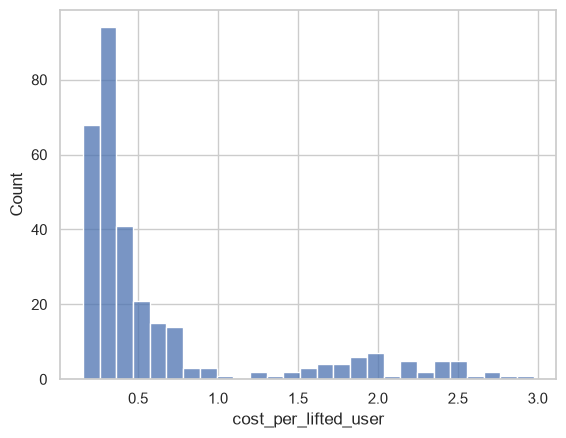

In [166]:
sns.histplot(result_df["cost_per_lifted_user"])
plt.show()

## Campaign-Level Metrrics

In [167]:
# Create one row per Campaign × Market × Channel
campaign_analysis = (
    result_df[
        result_df['is_significant'].notna()
    ]
    .groupby(
        ['Campaign_Name', 'Market', 'Channel'],
        as_index=False
    )
    .agg(
        Spend=('Spend_USD', 'sum'),
        Reach=('Reach', 'sum'),
        Conversions=('Conversions', 'sum'),
        Relative_Lift=('Relative_Lift', 'first'),
        Exposed_Rate=('Exposed_Rate', 'first'),
        Control_Rate=('Control_Rate', 'first'),
        pval=('pval', 'first'),
        is_significant=('is_significant', 'first'),
        absolute_lift=('abs_lift_pct', 'first')
    )
)

In [168]:
campaign_analysis['lifted_users'] = (
    campaign_analysis['Reach'] *
    campaign_analysis['absolute_lift']
)

campaign_analysis['CPLU'] = (
    campaign_analysis['Spend'] /
    campaign_analysis['lifted_users'].mask(
        campaign_analysis['lifted_users'] <= 0
    )
)

campaign_analysis['CPR'] = (
    campaign_analysis['Spend'] /
    campaign_analysis['Reach']
)

## Campaign Analysis

Most effective (highest relative lift)

In [169]:
#Sort by efficiency (lower cost per lifted user = better)
effective_campaigns = (
    campaign_analysis
    .sort_values(
        'Relative_Lift',
        ascending=False
    )
)

print("Most Effective Campaigns")
effective_campaigns[
    [
        'Campaign_Name',
        'Market',
        'Channel',
        'Relative_Lift',
        'pval'
    ]
].head(10)

Most Effective Campaigns


,Campaign_Name,Market,Channel,Relative_Lift,pval
20,BackToSchool_24,SA,YouTube,103.931185,1.168427e-36
40,NewYear_24,EG,Social,103.486838,1.357824e-31
8,BackToSchool_23,SA,YouTube,103.326807,1.376416e-29
5,BackToSchool_23,EG,YouTube,102.499071,5.807722e-24
43,NewYear_24,SA,Social,101.848708,1.031512e-30
28,ExamPrep_23,EG,Social,100.465267,1.038204e-22
7,BackToSchool_23,SA,Social,99.894886,1.419876e-34
32,ExamPrep_23,SA,YouTube,98.990967,4.648355e-35
14,BackToSchool_24,DE,YouTube,88.812339,3.190270e-17
35,ExamPrep_23,UK,YouTube,86.841477,1.074639e-15


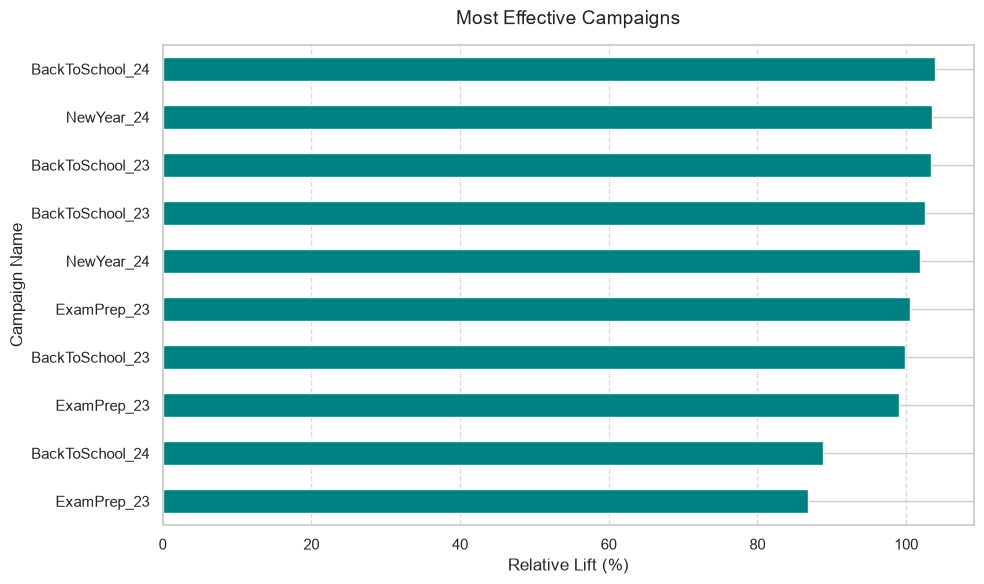

In [170]:
#Get the top 10 rows
most_effective = effective_campaigns.head(10)

#Reverse the order so the highest lift is at the top of the chart
most_effective_sorted = most_effective.sort_values('Relative_Lift', ascending=True)

ax = most_effective_sorted.plot.barh(
    x='Campaign_Name', 
    y='Relative_Lift', 
    color='teal', 
    figsize=(10, 6),
    legend=False
)

plt.title('Most Effective Campaigns', fontsize=14, pad=15)
plt.xlabel('Relative Lift (%)', fontsize=12)
plt.ylabel('Campaign Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Tight layout prevents cutting off long campaign names
plt.tight_layout()
plt.show()


Most efficient (lowest cost per lifted user)

In [171]:
# Sort statistically significant campaigns by Relative_Lift, highest first
efficient_campaigns = (
    campaign_analysis
    .sort_values(
        'CPLU',
        ascending=True
    )
)

print("Most Efficient Campaigns")
efficient_campaigns[
    [
        'Campaign_Name',
        'Market',
        'Channel',
        'CPLU',
        'Relative_Lift'
    ]
].head(10)

Most Efficient Campaigns


,Campaign_Name,Market,Channel,CPLU,Relative_Lift
5,BackToSchool_23,EG,YouTube,0.217829,102.499071
43,NewYear_24,SA,Social,0.222687,101.848708
8,BackToSchool_23,SA,YouTube,0.230694,103.326807
32,ExamPrep_23,SA,YouTube,0.236178,98.990967
7,BackToSchool_23,SA,Social,0.239437,99.894886
44,NewYear_24,SA,YouTube,0.244688,83.276361
40,NewYear_24,EG,Social,0.246443,103.486838
20,BackToSchool_24,SA,YouTube,0.251797,103.931185
28,ExamPrep_23,EG,Social,0.257774,100.465267
14,BackToSchool_24,DE,YouTube,0.259115,88.812339


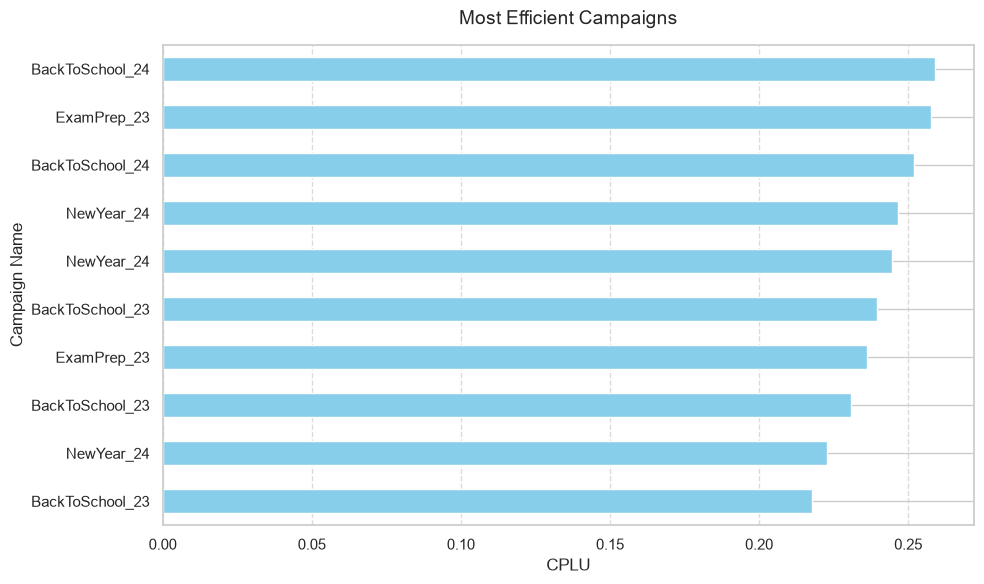

In [172]:
#Get the top 10 rows
most_efficient = efficient_campaigns.head(10)

#Reverse the order so the highest lift is at the top of the chart
most_efficient_sorted = most_efficient.sort_values('CPLU', ascending=True)

ax = most_efficient.plot.barh(
    x='Campaign_Name', 
    y='CPLU', 
    color='skyblue', 
    figsize=(10, 6),
    legend=False
)

plt.title('Most Efficient Campaigns', fontsize=14, pad=15)
plt.xlabel('CPLU', fontsize=12)
plt.ylabel('Campaign Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Market and Channel Analysis

Best Performing market/channel combinations

In [173]:
market_channel_analysis = (
    result_df
    .groupby(['Market', 'Channel'])
    .agg(
        Spend=('Spend_USD', 'sum'),
        Reach=('Reach', 'sum'),
        Lifted_Users=('lifted_users', 'sum')
    )
    .reset_index()
)

market_channel_analysis['CPLU'] = (
    market_channel_analysis['Spend'] /
    market_channel_analysis['Lifted_Users'].mask(
        market_channel_analysis['Lifted_Users'] <= 0 #No positive estimated lifted users were measured for these combinations, so CPLU is undefined.
    )
)

market_channel_analysis['CPR'] = (
    market_channel_analysis['Spend'] /
    market_channel_analysis['Reach']
)

market_channel_analysis = (
    market_channel_analysis
    .sort_values('CPLU')
)

market_channel_analysis

,Market,Channel,Spend,Reach,Lifted_Users,CPLU,CPR
11,SA,YouTube,586347,16322642,1.298375e+06,0.451601,0.035922
6,EG,Social,599752,16740556,1.182176e+06,0.507329,0.035826
7,EG,YouTube,579792,16700537,1.136869e+06,0.509990,0.034717
3,DE,YouTube,885143,25347834,1.664343e+06,0.531827,0.034920
10,SA,Social,577913,16033091,1.054470e+06,0.548060,0.036045
2,DE,Social,853339,23613823,1.458862e+06,0.584935,0.036137
14,UK,Social,892537,25319707,1.512776e+06,0.590000,0.035251
15,UK,YouTube,911210,25307489,1.499302e+06,0.607756,0.036006
4,EG,Display,390429,19749835,3.644865e+05,1.071175,0.019769
8,SA,Display,335932,17197782,2.834696e+05,1.185072,0.019533


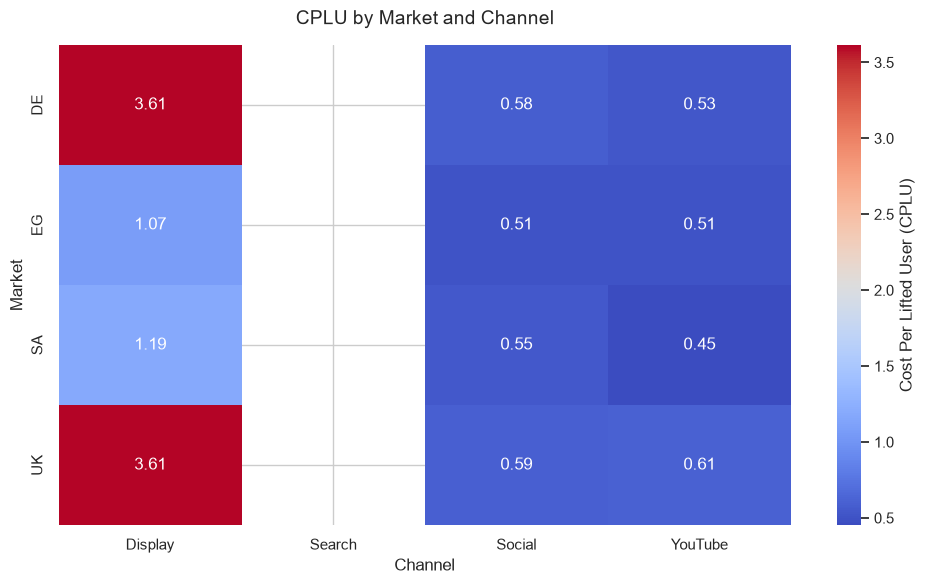

In [174]:
#Pivot the DataFrame to get 'Market' on rows and 'Channel' on columns
pivot_df = market_channel_analysis.pivot(
    index="Market", columns="Channel", values="CPLU"
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    pivot_df,
    annot=True,
    fmt=".2f", 
    cmap="coolwarm",
    cbar_kws={"label": "Cost Per Lifted User (CPLU)"}
)

plt.title("CPLU by Market and Channel", fontsize=14, pad=15)
plt.xlabel("Channel", fontsize=12)
plt.ylabel("Market", fontsize=12)

plt.tight_layout()
plt.show()

Relative cost to target by market/channel - which market/channel combinations are expensive to reach?

In [175]:

avg_cpr = market_channel_analysis['CPR'].mean()

market_channel_analysis['Relative_Cost_Index'] = (
    market_channel_analysis['CPR'] /
    avg_cpr
) * 100

most_expensive = (
    market_channel_analysis
    .sort_values(
        'Relative_Cost_Index',
        ascending=False
    )
)

# Which market/channel combinations are expensive to reach?
most_expensive

,Market,Channel,Spend,Reach,Lifted_Users,CPLU,CPR,Relative_Cost_Index
13,UK,Search,842667,9033397,0.000000e+00,NaN,0.093284,203.252362
9,SA,Search,583448,6294576,0.000000e+00,NaN,0.092691,201.960476
5,EG,Search,581230,6288476,0.000000e+00,NaN,0.092428,201.387878
1,DE,Search,903083,9779265,0.000000e+00,NaN,0.092347,201.211206
2,DE,Social,853339,23613823,1.458862e+06,0.584935,0.036137,78.738294
10,SA,Social,577913,16033091,1.054470e+06,0.548060,0.036045,78.537291
15,UK,YouTube,911210,25307489,1.499302e+06,0.607756,0.036006,78.451298
11,SA,YouTube,586347,16322642,1.298375e+06,0.451601,0.035922,78.269933
6,EG,Social,599752,16740556,1.182176e+06,0.507329,0.035826,78.060717
14,UK,Social,892537,25319707,1.512776e+06,0.590000,0.035251,76.806551


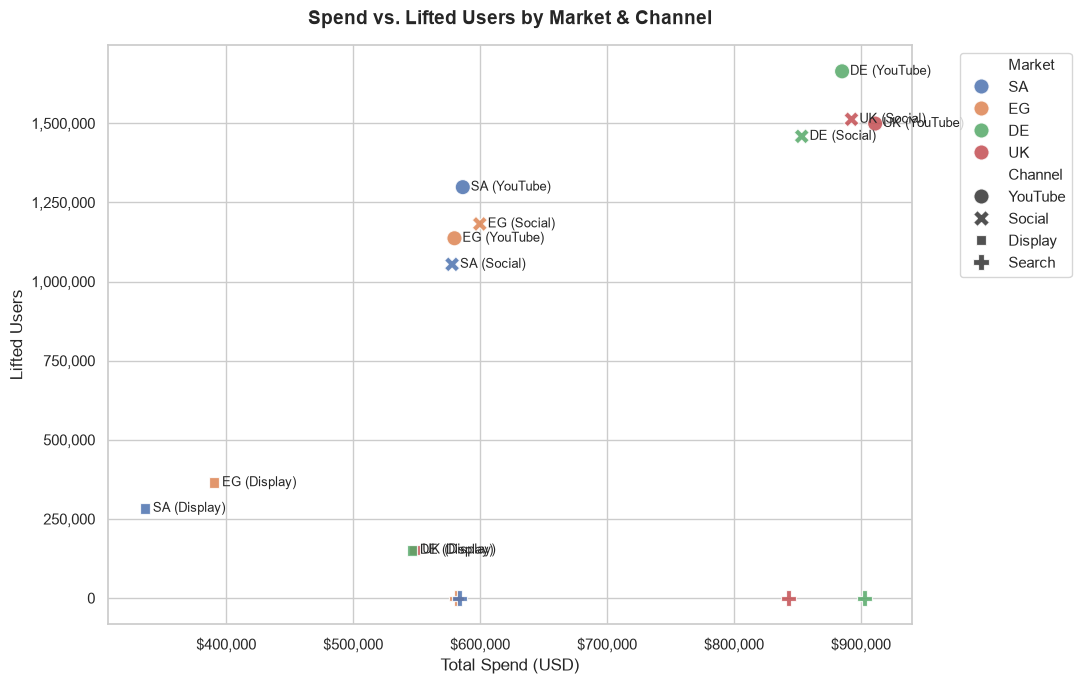

In [176]:
# 1. Set figure size and style
plt.figure(figsize=(11, 7))
sns.set_theme(style="whitegrid")

# 2. Create scatter plot
# Color points by Market (or Channel) and size by Reach
ax = sns.scatterplot(
    data=market_channel_analysis,
    x="Spend",
    y="Lifted_Users",
    hue="Market",  # Distinct colors for each Market
    style="Channel",  # Distinct markers for each Channel
    s=120,  # Marker size
    alpha=0.85,
)

# 3. Annotate each data point with its 'Market - Channel' label
for idx, row in market_channel_analysis.iterrows():
    # Only label points where Lifted_Users is valid/measured
    if pd.notna(row["Lifted_Users"]) and row["Lifted_Users"] > 0:
        plt.text(
            x=row["Spend"],
            y=row["Lifted_Users"],
            s=f"  {row['Market']} ({row['Channel']})",
            fontsize=9,
            va="center",
        )

# 4. Add labels, title, and legend
plt.title(
    "Spend vs. Lifted Users by Market & Channel", fontsize=14, pad=15, weight="bold"
)
plt.xlabel("Total Spend (USD)", fontsize=12)
plt.ylabel("Lifted Users", fontsize=12)

# Format axes numbers with commas for readability
ax.xaxis.set_major_formatter("${x:,.0f}")
ax.yaxis.set_major_formatter("{x:,.0f}")

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", frameon=True)
plt.tight_layout()

plt.show()

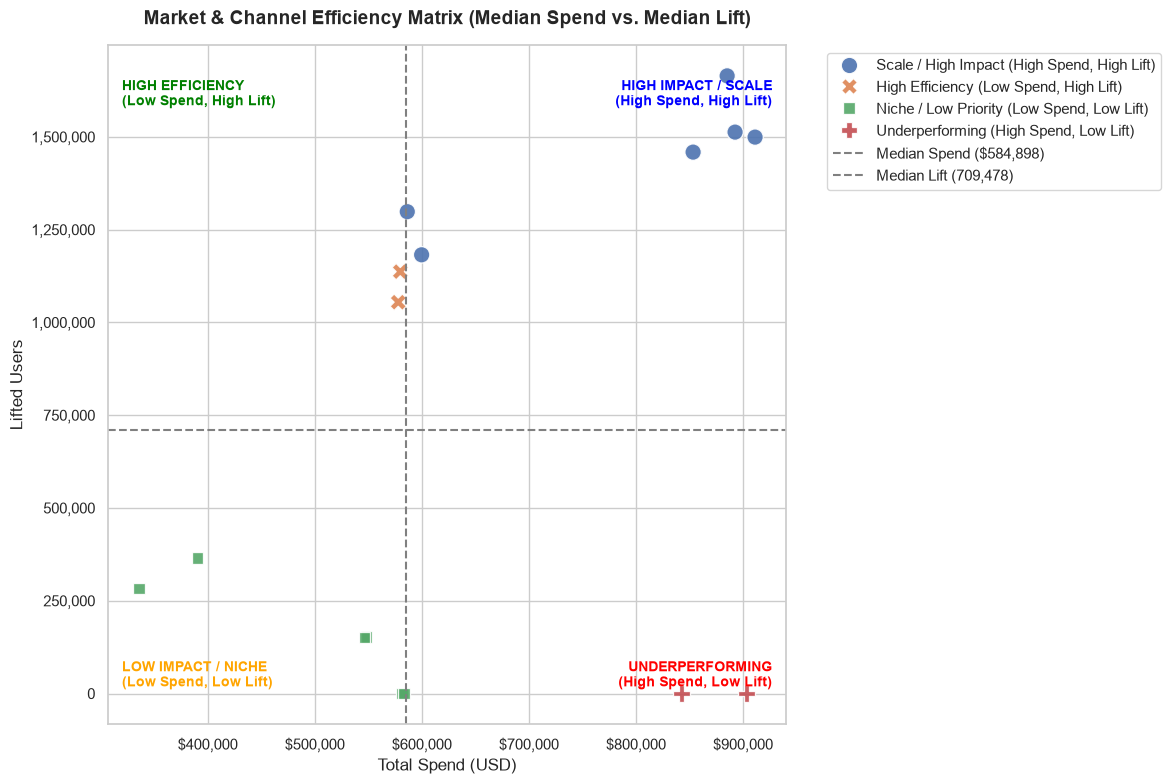

In [177]:
# 1. Calculate medians for the reference lines
med_spend = market_channel_analysis["Spend"].median()
med_lift = market_channel_analysis["Lifted_Users"].median()

# 2. Categorize data points into quadrants (for automated coloring/legend)
def assign_quadrant(row):
    if row["Spend"] <= med_spend and row["Lifted_Users"] >= med_lift:
        return "High Efficiency (Low Spend, High Lift)"
    elif row["Spend"] > med_spend and row["Lifted_Users"] >= med_lift:
        return "Scale / High Impact (High Spend, High Lift)"
    elif row["Spend"] <= med_spend and row["Lifted_Users"] < med_lift:
        return "Niche / Low Priority (Low Spend, Low Lift)"
    else:
        return "Underperforming (High Spend, Low Lift)"

market_channel_analysis["Quadrant"] = market_channel_analysis.apply(
    assign_quadrant, axis=1
)

# 3. Create scatter plot colored by quadrant
plt.figure(figsize=(12, 8))

ax = sns.scatterplot(
    data=market_channel_analysis,
    x="Spend",
    y="Lifted_Users",
    hue="Quadrant",
    style="Quadrant",
    s=140,
    alpha=0.9,
)

# 4. Draw the median quadrant dividing lines
plt.axvline(
    x=med_spend,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label=f"Median Spend (${med_spend:,.0f})",
)
plt.axhline(
    y=med_lift,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label=f"Median Lift ({med_lift:,.0f})",
)

# 5. Label the 4 quadrants directly on the plot
# Using transform=ax.transAxes allows positioning relative to axis boundaries (0.0 to 1.0)
ax.text(
    0.02,
    0.95,
    "HIGH EFFICIENCY\n(Low Spend, High Lift)",
    transform=ax.transAxes,
    fontsize=10,
    fontweight="bold",
    color="green",
    va="top",
)

ax.text(
    0.98,
    0.95,
    "HIGH IMPACT / SCALE\n(High Spend, High Lift)",
    transform=ax.transAxes,
    fontsize=10,
    fontweight="bold",
    color="blue",
    ha="right",
    va="top",
)

ax.text(
    0.02,
    0.05,
    "LOW IMPACT / NICHE\n(Low Spend, Low Lift)",
    transform=ax.transAxes,
    fontsize=10,
    fontweight="bold",
    color="orange",
    va="bottom",
)

ax.text(
    0.98,
    0.05,
    "UNDERPERFORMING\n(High Spend, Low Lift)",
    transform=ax.transAxes,
    fontsize=10,
    fontweight="bold",
    color="red",
    ha="right",
    va="bottom",
)

# 6. Format axes and title
plt.title(
    "Market & Channel Efficiency Matrix (Median Spend vs. Median Lift)",
    fontsize=14,
    pad=15,
    weight="bold",
)
plt.xlabel("Total Spend (USD)", fontsize=12)
plt.ylabel("Lifted Users", fontsize=12)

ax.xaxis.set_major_formatter("${x:,.0f}")
ax.yaxis.set_major_formatter("{x:,.0f}")

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Creative Performance Analysis

Which creative resonated best globally?

In [178]:
# Average consideration lift across all markets/age groups, per creative

global_creative_performance = (
    creative_df
    .groupby('Creative_Name')
    ['Point_Est_Consideration']
    .mean()
    .sort_values(ascending=False)
)

global_creative_performance

Creative_Name
Life Hack        5.512917
Coding Help      3.079583
Study With Me    2.261875
Grade Booster    1.626250
Free Trial       1.065000
Name: Point_Est_Consideration, dtype: float64

Does Creative performance differ by market (Resonance by market)

In [179]:
creative_market_performance = (
    creative_df
    .groupby(
        ['Market', 'Creative_Name']
    )['Point_Est_Consideration']
    .mean()
    .reset_index()
)

creative_market_performance

,Market,Creative_Name,Point_Est_Consideration
0,DE,Coding Help,2.722500
1,DE,Free Trial,1.078333
2,DE,Grade Booster,1.660000
3,DE,Life Hack,6.313333
4,DE,Study With Me,2.210000
5,EG,Coding Help,3.512500
6,EG,Free Trial,1.072500
7,EG,Grade Booster,1.583333
8,EG,Life Hack,4.724167
9,EG,Study With Me,2.320833


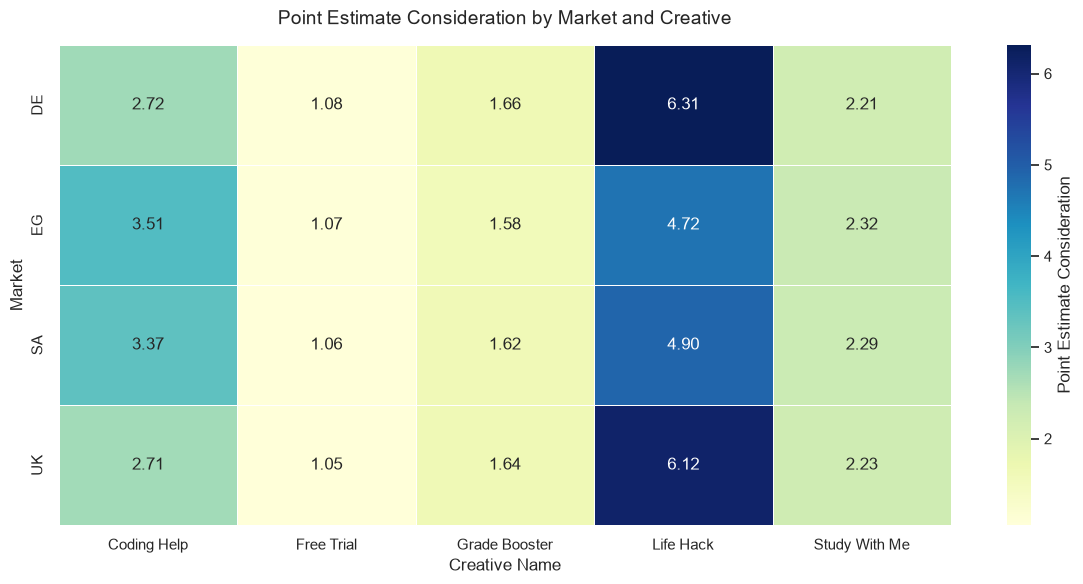

In [180]:
# 1. Pivot the DataFrame
pivot_df = creative_market_performance.pivot(
    index="Market", columns="Creative_Name", values="Point_Est_Consideration"
)

# 2. Set up the figure dimensions
plt.figure(figsize=(12, 6))

# 3. Render the heatmap
sns.heatmap(
    pivot_df,
    annot=True,  # Displays numbers inside cells
    fmt=".2f",  # Formats numbers to 2 decimal places
    cmap="YlGnBu",  # Color gradient palette
    cbar_kws={"label": "Point Estimate Consideration"},
    linewidths=0.5,
)

# 4. Add title and labels
plt.title(
    "Point Estimate Consideration by Market and Creative", fontsize=14, pad=15
)
plt.xlabel("Creative Name", fontsize=12)
plt.ylabel("Market", fontsize=12)

# 5. Display plot
plt.tight_layout()
plt.show()

Which channel is best for resonance? (Resonance by channel)

In [181]:
creative_channel_performance = (
    creative_df
    .groupby(
        ['Channel', 'Creative_Name']
    )['Point_Est_Consideration']
    .mean()
    .reset_index()
)

creative_channel_performance

,Channel,Creative_Name,Point_Est_Consideration
0,Display,Coding Help,1.309167
1,Display,Free Trial,0.475000
2,Display,Grade Booster,0.728333
3,Display,Life Hack,2.451667
4,Display,Study With Me,0.995000
5,Search,Coding Help,0.700000
6,Search,Free Trial,0.239167
7,Search,Grade Booster,0.361667
8,Search,Life Hack,1.229167
9,Search,Study With Me,0.513333


## Deeper Analysis

### Is higher spend actually more effective? Spend vs Impact
Comparing spend against *scale* (lifted users) vs spend against *efficiency* (relative lift) separates "this campaign had a big budget" from "this campaign had a good strategy."

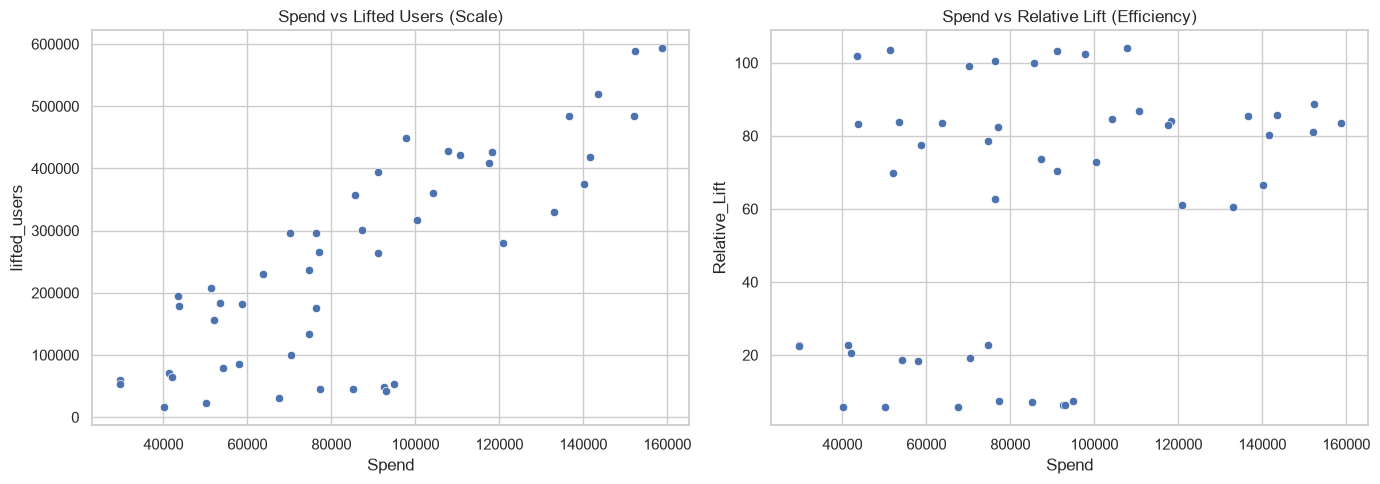

Correlation: Spend vs Lifted Users  -> 0.803
Correlation: Spend vs Relative Lift -> 0.375


In [182]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=campaign_analysis, x='Spend', y='lifted_users', ax=axes[0])
axes[0].set_title('Spend vs Lifted Users (Scale)')

sns.scatterplot(data=campaign_analysis, x='Spend', y='Relative_Lift', ax=axes[1])
axes[1].set_title('Spend vs Relative Lift (Efficiency)')

plt.tight_layout()
plt.show()

# A strong Spend-vs-Lifted-Users correlation with a weak Spend-vs-Relative-Lift correlation
# means spend buys scale, not necessarily a better campaign strategy.
print("Correlation: Spend vs Lifted Users  ->", campaign_analysis['Spend'].corr(campaign_analysis['lifted_users']).round(3))
print("Correlation: Spend vs Relative Lift ->", campaign_analysis['Spend'].corr(campaign_analysis['Relative_Lift']).round(3))

### High lift vs high efficiency (CPLU)

Plotting Relative Lift against CPLU and splitting on the medians turns two separate rankings into a single quadrant view: which campaigns are genuinely best (high lift, low cost), and which are just expensive or just underperforming. Lower CPLU is more efficient, Higher relative lift is more effective

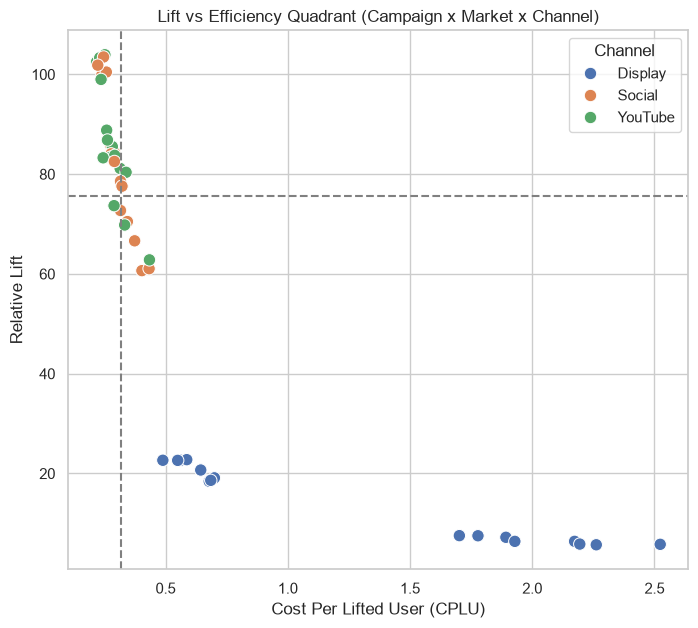

In [183]:
plot_df = campaign_analysis.copy()

median_cplu = plot_df['CPLU'].median()
median_lift = plot_df['Relative_Lift'].median()

plt.figure(figsize=(8, 7))
sns.scatterplot(data=plot_df, x='CPLU', y='Relative_Lift', hue='Channel', s=80)
plt.axvline(median_cplu, color='gray', linestyle='--')
plt.axhline(median_lift, color='gray', linestyle='--')
plt.title('Lift vs Efficiency Quadrant (Campaign x Market x Channel)')
plt.xlabel('Cost Per Lifted User (CPLU)')
plt.ylabel('Relative Lift')
plt.show()

In [184]:
def classify_quadrant(row):
    if row['Relative_Lift'] >= median_lift and row['CPLU'] <= median_cplu:
        return 'Best performers'
    elif row['Relative_Lift'] >= median_lift and row['CPLU'] > median_cplu:
        return 'Effective but expensive'
    elif row['Relative_Lift'] < median_lift and row['CPLU'] <= median_cplu:
        return 'Efficient but limited impact'
    else:
        return 'Weak performers'

plot_df['performance_quadrant'] = plot_df.apply(classify_quadrant, axis=1)

print(plot_df['performance_quadrant'].value_counts())

# The campaigns to lead your recommendations with
plot_df[plot_df['performance_quadrant'] == 'Best performers'][
    ['Campaign_Name', 'Market', 'Channel', 'Relative_Lift', 'CPLU']
].sort_values('Relative_Lift', ascending=False)

performance_quadrant
Weak performers                 22
Best performers                 22
Effective but expensive          2
Efficient but limited impact     2
Name: count, dtype: int64


,Campaign_Name,Market,Channel,Relative_Lift,CPLU
20,BackToSchool_24,SA,YouTube,103.931185,0.251797
40,NewYear_24,EG,Social,103.486838,0.246443
8,BackToSchool_23,SA,YouTube,103.326807,0.230694
5,BackToSchool_23,EG,YouTube,102.499071,0.217829
43,NewYear_24,SA,Social,101.848708,0.222687
28,ExamPrep_23,EG,Social,100.465267,0.257774
7,BackToSchool_23,SA,Social,99.894886,0.239437
32,ExamPrep_23,SA,YouTube,98.990967,0.236178
14,BackToSchool_24,DE,YouTube,88.812339,0.259115
35,ExamPrep_23,UK,YouTube,86.841477,0.262315


### Does the best creative depend on the market/channel? (Creative x Market/Channel)

The global ranking says one creative wins on average. Breaking it down by Market × Channel checks whether that holds everywhere, or whether different concepts actually win in different pockets — which changes the recommendation from "use Creative X" to "tailor creative by market/channel."

In [185]:
creative_by_market_channel = (
    creative_df
    .groupby(['Market', 'Channel', 'Creative_Name'])['Point_Est_Consideration']
    .mean()
    .reset_index()
)

# Top-performing creative for each Market x Channel combination
best_creative_per_combo = (
    creative_by_market_channel
    .sort_values('Point_Est_Consideration', ascending=False)
    .groupby(['Market', 'Channel'])
    .first()
    .reset_index()
)

best_creative_per_combo

,Market,Channel,Creative_Name,Point_Est_Consideration
0,DE,Display,Life Hack,2.800000
1,DE,Search,Life Hack,1.310000
2,DE,Social,Life Hack,10.916667
3,DE,YouTube,Life Hack,10.226667
4,EG,Display,Life Hack,2.086667
5,EG,Search,Life Hack,1.063333
6,EG,Social,Life Hack,7.590000
7,EG,YouTube,Life Hack,8.156667
8,SA,Display,Life Hack,2.236667
9,SA,Search,Life Hack,1.106667


## Recommendations

Based on the analysis of campaign performance, brand lift, market and channel efficency, and creative resonance. Several Recommendations can be made for future Gemini Pro marketing campaign

##### 1. Prioritise campaigns that combine strong brand lift with cost efficiency.

Campaign effectiveness are evaluated using relative lift and CPLU. The analysis identified BackToSchool_24 in SA market using Youtube with the highest statistically significant relative lift at 103.93%. In contrast, ExamPrep_23 using YouTube is SA market, achieved the lowest CPLU of approximately $0.15, which demonstrate that this campaign are very cost effienct.

These results show that the campaign with the greatest impact(Relative lift) is not necessarily the campaign that generates that impact at the lowest cost. Therefore, furture budget allocation chould prioritise campaign and channel combinations that demonstrate statistically significant relative lift with high cost effiency.


##### 2. Prioritise YouTube and Social for brand-consideration objectives

YouTube and Social demonstrated the strongest creative consideration performance, with average consideration scores of approximately 4.53 and 4.49 respectively. In comparison, Search had a substantially higher cost per reach than Display, indicating that Search was more expensive for reaching users within the analysed campaigns.

Therefore, YouTube and Social should be prioritised when the primary objective is increasing brand consideration. However, Search should not necessarily be removed from the marketing strategy, as it may support other objectives that are not measured in this dataset. Its future investment should instead be evaluated against additional performance metrics.

##### 3. Adapt creative strategy to individual markets

Life Hack was the strongest-performing creative globally, with an average consideration score of approximately 5.51. However, its performance varied across markets. It performed particularly strongly in the UK and DE markets, while Coding Help performed relatively well in EG and SA markets.

This suggests that a single global creative strategy may not produce the strongest results in every market. Gemini should therefore consider adapting creative selection to individual markets. Life Hack could be prioritised or tested further in the UK and DE markets, while Coding Help could be tested more heavily in EG and SD markets.

##### 4. Evaluate channel investment using both cost and impact

The analysis showed substantial differences in the cost of reaching users across channels, with Search being considerably more expensive than Display. At the same time, some Search combinations did not produce positive estimated lifted users in the available brand-lift data.

Therefore, Gemini should evaluate channel investment based on both the cost of reaching users and the measurable brand impact generated. Higher-cost channels should not automatically receive additional investment simply because they generate reach. Their value should be assessed against the specific marketing objective and additional performance metrics.

## Limitations

- Brand-lift measurements are available only for a subset of historical campaigns.
- Brand-lift data is campaign-level whereas historical performance is weekly.
- Lifted users are an estimated metric derived from reach × absolute lift.
- Correlation between spend and impact does not establish causation.
- Creative performance is based on point-estimate consideration scores.
- The analysis does not include factors such as audience composition, seasonality, creative spend, or auction conditions.

1. Limited availability of brand-lift measurements

Brand-lift measurements were only available for a subset of the historical campaigns. Therefore, campaigns without a corresponding brand-lift study cannot be directly evaluated for statistical brand impact. A lack of a brand-lift result should not be interpreted as evidence that a campaign did not generate lift; rather, no measurement was available for that campaign.

2. Lifted users are an estimate

Estimated lifted users were calculated by multiplying campaign reach by absolute lift. This provides an estimate of the number of users potentially influenced by the campaign rather than a directly observed count of individual users. Therefore, lifted-user and CPLU results should be interpreted as estimated measures of efficiency.

3. Different levels of data granularity

The historical campaign dataset contains weekly campaign observations, whereas the brand-lift dataset contains campaign-level measurements by market and channel. As a result, the same campaign-level brand-lift measurement can be associated with multiple weekly observations after the datasets are merged. This means the analysis cannot be used to determine how brand lift changed from one week to another.

4. Association does not necessarily imply causation

The analysis identifies relationships between markets, channels, creatives, campaign spending and brand lift. However, these relationships do not necessarily prove that a particular channel or creative caused the observed performance. Other factors, such as campaign budget, audience characteristics, timing, seasonality and differences in campaign execution, may also have influenced the results.

5. Creative performance may differ between audiences

Creative performance was primarily evaluated using average consideration scores across markets and audience groups. Although this provides a useful overall comparison, averaging results can hide differences between specific audience segments. Therefore, a creative that performs strongly overall may not necessarily be the most effective option for every market or audience.

6. Statistical significance does not equal business importance

The statistical significance test determines whether an observed difference is unlikely to have occurred due to sampling variation. However, statistical significance alone does not indicate whether an effect is large enough to be practically important or valuable to the business. For this reason, statistical significance was considered alongside relative lift, estimated lifted users and cost efficiency when evaluating campaigns.

## Export Result

In [ ]:
from pathlib import Path

# Define directory and ensure it exists
output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

# Export using path division syntax
result_df.to_csv(output_dir / "processed_campaign_analysis.csv", index=False)

market_channel_analysis.to_csv(output_dir / "market_channel_analysis.csv", index=False)

creative_market_performance.to_csv(output_dir / "creative_market_performance.csv", index=False)